In [ ]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly, find_peaks
import neurokit2 as nk
import rsp.data_processing.signal_processing as signal_processing
from rsp.plotting import Rsp_Kit

import importlib
importlib.reload(signal_processing)
importlib.reload(Rsp_Kit)

<module 'rsp.plotting.Rsp_Kit' from 'C:\\Users\\thoma\\Code\\ResearchCode\\respiratory_pilot\\src\\rsp\\plotting\\Rsp_Kit.py'>

In [ ]:
pd.set_option('display.max_colwidth', 0)  # 0 means unlimited in newer pandas versions

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Don’t truncate column contents
pd.set_option("display.max_colwidth", None)

# Expand the display to the full width of the screen
pd.set_option("display.width", 0)


In [ ]:
RI1_4_7_h5_path = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\updated_meta_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"
RI2_4_7_h5_path = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\updated_meta_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"

RI1_4_7_b_path = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\Data\behavior_aim1\RI1_s4_7_p5_2_nRB3_HEEPS_good.csv"
RI2_4_7_b_path = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\Data\behavior_aim1\RI2_s4_7_p5_2_nRB3_HEEPS_good.csv"

In [ ]:
RI1_4_7_boris = pd.read_csv(RI1_4_7_b_path)
RI2_4_7_boris = pd.read_csv(RI2_4_7_b_path)

### Filtering out social_agent so only subject behaviors plotted

In [ ]:
# taking out all rows with subject=social_agent
RI1_4_7_boris = RI1_4_7_boris[RI1_4_7_boris['Subject'] != 'social_agent']
RI2_4_7_boris = RI2_4_7_boris[RI2_4_7_boris['Subject'] != 'social_agent']

In [ ]:
RI1_4_7_boris.head(20)

,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,Observation duration by subject by observation,Behavior,Behavioral category,Behavior type,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop
1,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.8,30.0,subject,47.492,anogenital sniffing,Not defined,STATE,13.633,13.733,0.100,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,409,412.0,NaN,NaN,NaN,NaN
2,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.8,30.0,subject,47.492,anogenital sniffing,Not defined,STATE,16.000,17.733,1.733,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,480,532.0,NaN,NaN,NaN,NaN
3,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.8,30.0,subject,47.492,anogenital sniffing,Not defined,STATE,19.233,20.367,1.134,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,577,611.0,NaN,NaN,NaN,NaN
4,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.8,30.0,subject,47.492,anogenital sniffing,Not defined,STATE,21.633,23.532,1.899,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,649,NaN,NaN,NaN,NaN,NaN
5,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.8,30.0,subject,47.492,body sniffing,Not defined,STATE,23.533,24.099,0.566,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,706,NaN,NaN,NaN,NaN,NaN
6,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.8,30.0,subject,47.492,facial sniffing,Not defined,STATE,24.100,25.333,1.233,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,723,760.0,NaN,NaN,NaN,NaN
8,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.8,30.0,subject,47.492,facial sniffing,Not defined,STATE,26.100,27.567,1.467,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,783,827.0,NaN,NaN,NaN,NaN
9,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.8,30.0,subject,47.492,anogenital sniffing,Not defined,STATE,31.500,32.633,1.133,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,945,979.0,NaN,NaN,NaN,NaN
10,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.8,30.0,subject,47.492,body sniffing,Not defined,STATE,33.100,34.367,1.267,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,993,1031.0,NaN,NaN,NaN,NaN
11,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.8,30.0,subject,47.492,anogenital sniffing,Not defined,STATE,34.733,37.600,2.867,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,1042,1128.0,NaN,NaN,NaN,NaN


### Function to quickly get read and filter resp data and create Rsp_Kit object with behavior

In [ ]:
def get_kit(h5_file, target_rate=100, behavior_data=None):
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
    except Exception as e:
        return {"file": os.path.basename(h5_file), "error": str(e)}

    try:
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except KeyError:
        return {"file": os.path.basename(h5_file), "error": "Missing 'duration_sec' metadata"}

    # Step 1: Pre-downsampling apply low-pass filter
    cutoff_hz = target_rate / 2
    nyquist = fs / 2
    norm_cutoff = cutoff_hz / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Step 2: Downsample
    downsample_factor = int(fs // target_rate)
    downsampled_resp = resample_poly(filtered_resp, up=1, down=downsample_factor)
    duration_downsampled = len(downsampled_resp) / target_rate

    # Step 3: Apply neurokit2 Butterworth bandpass filter after downsampling
    rsp_cleaned = nk.signal_filter(
        downsampled_resp,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    return Rsp_Kit.Rsp_Kit(rsp_cleaned, fs=target_rate, n_samples=len(rsp_cleaned), behavior_data=behavior_data)


In [ ]:
RI2_4_7_kit = get_kit(RI2_4_7_h5_path, target_rate=100, behavior_data=RI2_4_7_boris) 
RI1_4_7_kit = get_kit(RI1_4_7_h5_path, target_rate=100, behavior_data=RI1_4_7_boris)

Index(['Timestamps', 'Respiration Value', 'Behavioral Event', 'Peaks'], dtype='object')
Behavioral data is present, overlaying behavior events.


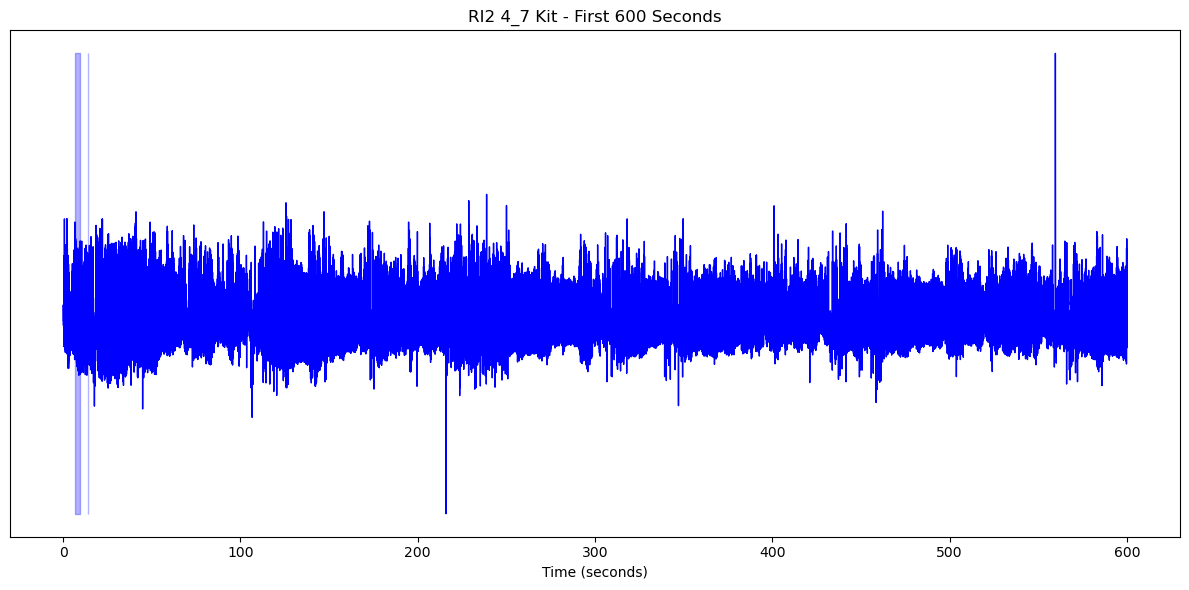

Index(['Timestamps', 'Respiration Value', 'Behavioral Event', 'Peaks'], dtype='object')
Behavioral data is present, overlaying behavior events.


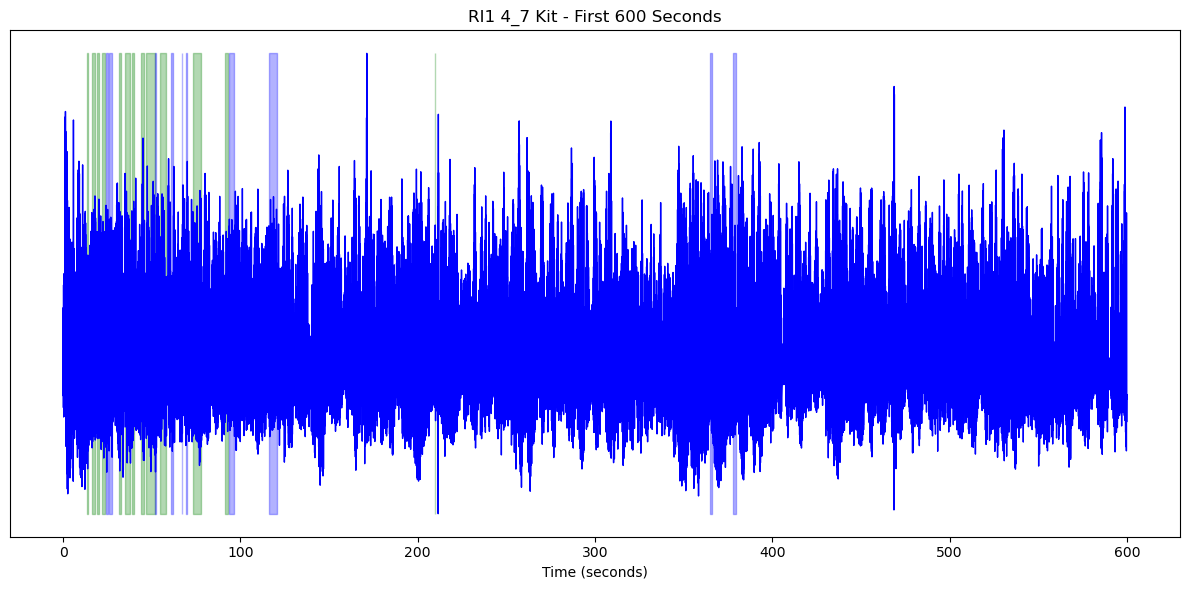

In [ ]:
RI2_4_7_kit.plot(duration=600, behavior_data=True, title="RI2 4_7 Kit")
RI1_4_7_kit.plot(duration=600, behavior_data=True, title="RI1 4_7 Kit")

Index(['Timestamps', 'Respiration Value', 'Behavioral Event', 'Peaks'], dtype='object')
Behavioral data is present, overlaying behavior events.


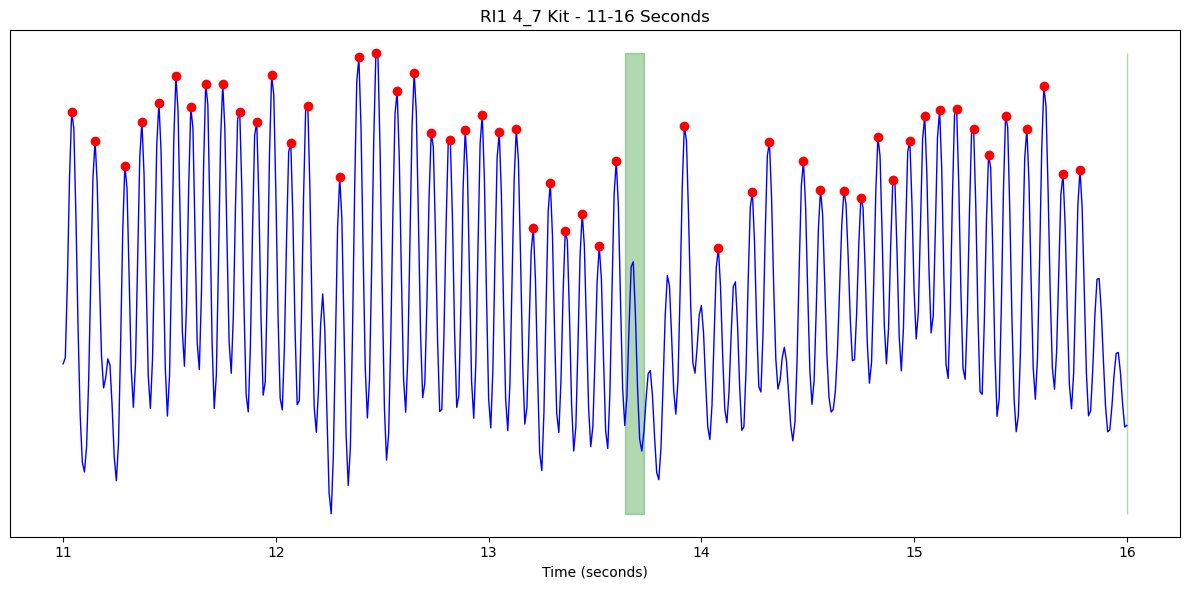

In [ ]:
RI1_4_7_kit.plot(start_time=11, duration=5, behavior_data=True, show_peaks=True, title="RI1 4_7 Kit")

Index(['Timestamps', 'Respiration Value', 'Behavioral Event', 'Peaks'], dtype='object')
Behavioral data is present, overlaying behavior events.


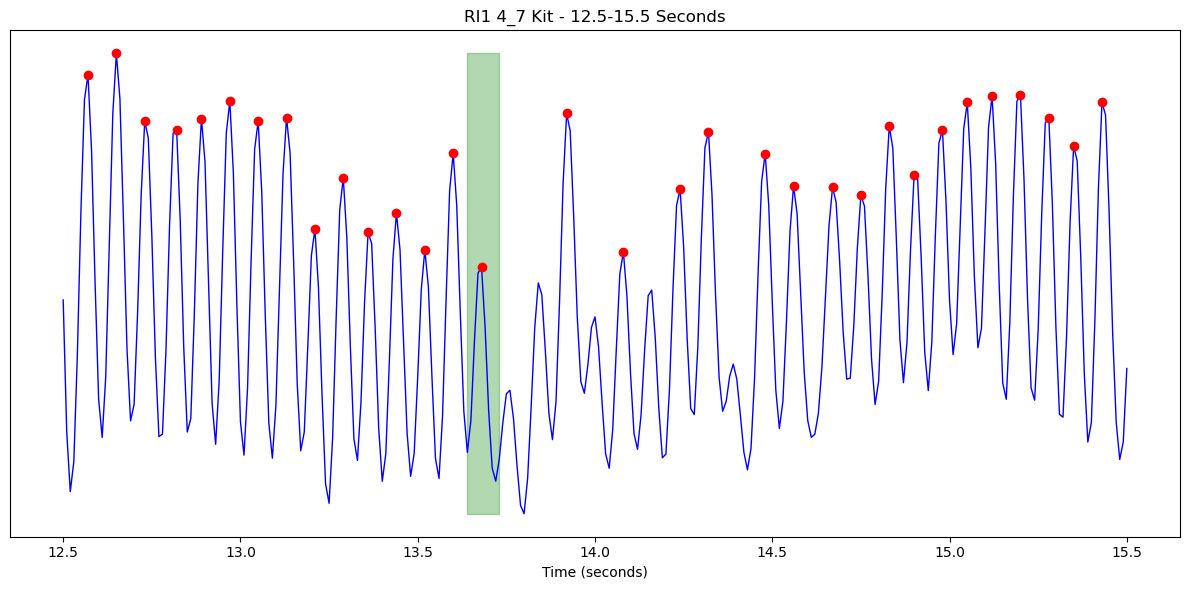

In [ ]:
RI1_4_7_kit.plot(start_time=12.5, duration=3, behavior_data=True, show_peaks=True, title="RI1 4_7 Kit")

In [ ]:
RI1_4_7_kit

Index(['Timestamps', 'Respiration Value', 'Behavioral Event', 'Peaks'], dtype='object')
Behavioral data is present, overlaying behavior events.


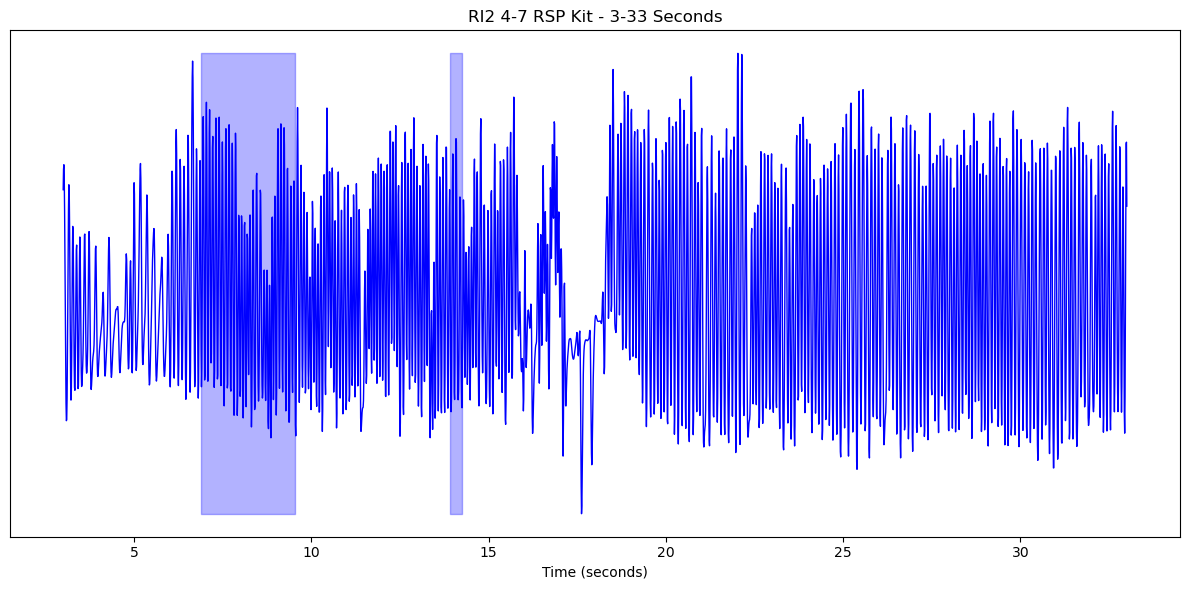

In [ ]:
RI2_4_7_kit.plot(start_time=3, duration=30, behavior_data=True, title="RI2 4-7 RSP Kit")

In [ ]:
importlib.reload(Rsp_Kit)

<module 'rsp.plotting.Rsp_Kit' from 'C:\\Users\\thoma\\Code\\ResearchCode\\respiratory_pilot\\src\\rsp\\plotting\\Rsp_Kit.py'>

Index(['Timestamps', 'Respiration Value', 'Behavioral Event', 'Peaks'], dtype='object')
Behavioral data is present, overlaying behavior events.


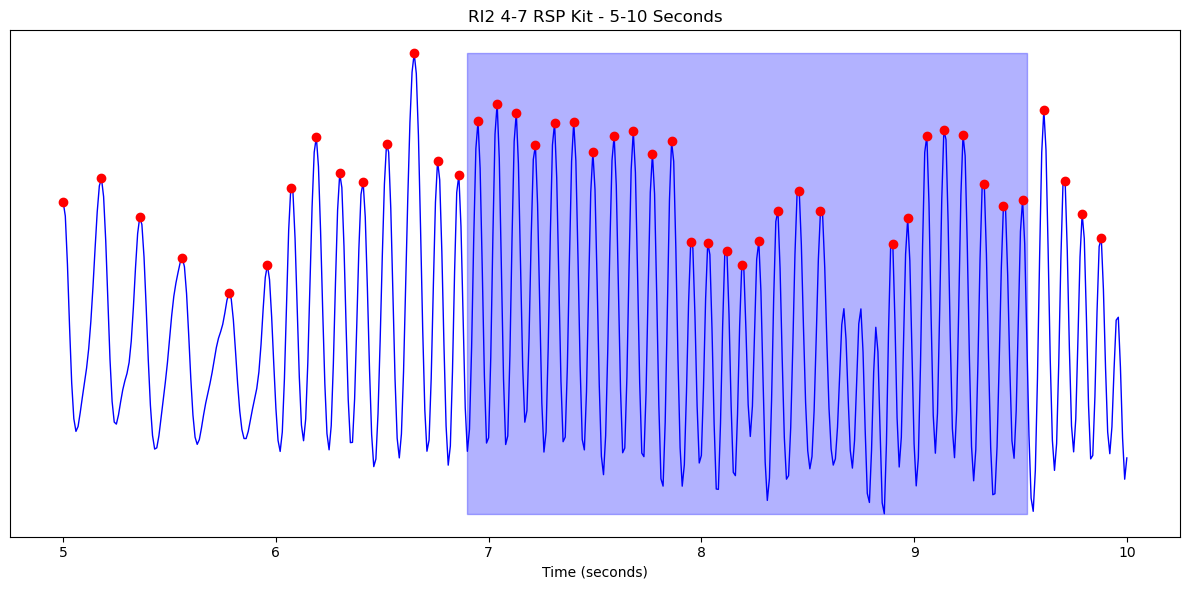

In [ ]:
RI2_4_7_kit.plot(start_time=5, duration=5, behavior_data=True, show_peaks=True, title="RI2 4-7 RSP Kit")

Index(['Timestamps', 'Respiration Value', 'Behavioral Event', 'Peaks'], dtype='object')
Behavioral data is present, overlaying behavior events.


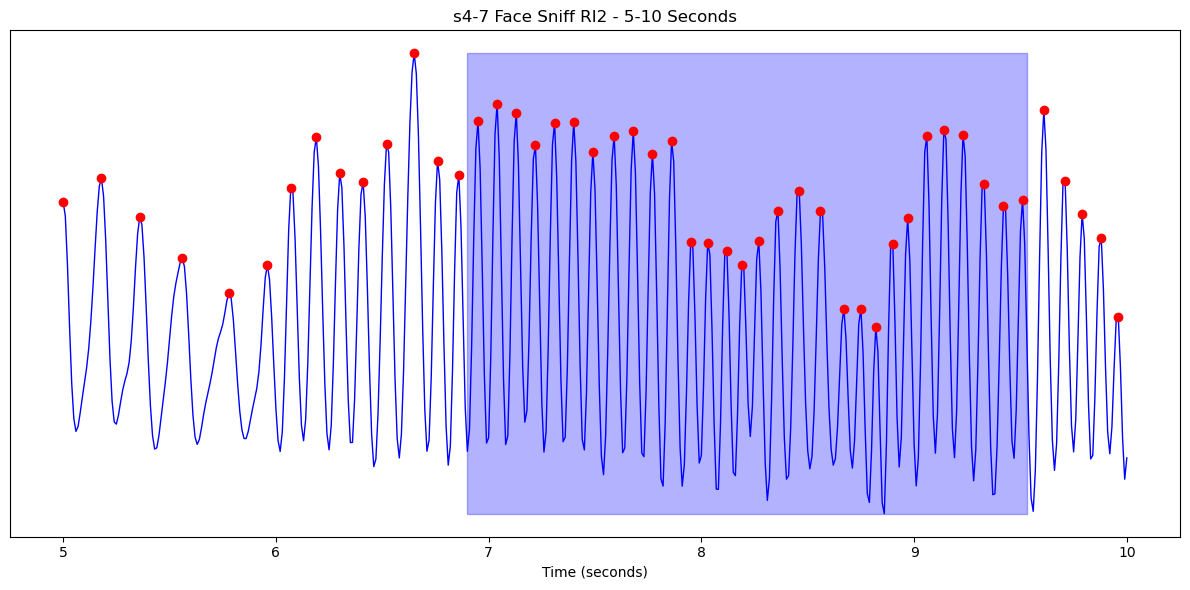

In [ ]:
RI2_4_7_kit.plot(start_time=5, duration=5, behavior_data=True, peak_sel=.1, peak_thresh=.5, show_peaks=True, title="s4-7 Face Sniff RI2")

In [ ]:
RI2_4_7_boris.head(20)

,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,Observation duration by subject by observation,Behavior,Behavioral category,Behavior type,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop
1,RI2_s4_7_p5_2_nRB3,2025-07-01 08:59:12.130,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,0.0,598.466,605.233,30.0,subject,136.8,facial sniffing,Not defined,STATE,6.900,9.533,2.633,C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,207.0,286.0,NaN,NaN,NaN,NaN
3,RI2_s4_7_p5_2_nRB3,2025-07-01 08:59:12.130,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,0.0,598.466,605.233,30.0,subject,136.8,facial sniffing,Not defined,STATE,13.900,14.267,0.367,C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,417.0,428.0,NaN,NaN,NaN,NaN
7,RI2_s4_7_p5_2_nRB3,2025-07-01 08:59:12.130,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,0.0,598.466,605.233,30.0,subject,136.8,Posturing,Not defined,STATE,18.833,20.667,1.834,C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,565.0,620.0,NaN,NaN,NaN,NaN
15,RI2_s4_7_p5_2_nRB3,2025-07-01 08:59:12.130,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,0.0,598.466,605.233,30.0,subject,136.8,Posturing,Not defined,STATE,46.100,52.100,6.000,C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,1383.0,1563.0,NaN,NaN,NaN,NaN
31,RI2_s4_7_p5_2_nRB3,2025-07-01 08:59:12.130,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,0.0,598.466,605.233,30.0,subject,136.8,Posturing,Not defined,STATE,132.867,141.767,8.900,C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,3986.0,4253.0,NaN,NaN,NaN,NaN
49,RI2_s4_7_p5_2_nRB3,2025-07-01 08:59:12.130,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,0.0,598.466,605.233,30.0,subject,136.8,Posturing,Not defined,STATE,259.367,269.300,9.933,C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,7781.0,8079.0,NaN,NaN,NaN,NaN
54,RI2_s4_7_p5_2_nRB3,2025-07-01 08:59:12.130,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,0.0,598.466,605.233,30.0,subject,136.8,Posturing,Not defined,STATE,322.433,338.667,16.234,C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,9674.0,10161.0,NaN,NaN,NaN,NaN
59,RI2_s4_7_p5_2_nRB3,2025-07-01 08:59:12.130,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,0.0,598.466,605.233,30.0,subject,136.8,Posturing,Not defined,STATE,356.300,382.300,26.000,C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,10690.0,11470.0,NaN,NaN,NaN,NaN
65,RI2_s4_7_p5_2_nRB3,2025-07-01 08:59:12.130,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,0.0,598.466,605.233,30.0,subject,136.8,Posturing,Not defined,STATE,409.167,422.267,13.100,C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,12276.0,12669.0,NaN,NaN,NaN,NaN
72,RI2_s4_7_p5_2_nRB3,2025-07-01 08:59:12.130,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,0.0,598.466,605.233,30.0,subject,136.8,Posturing,Not defined,STATE,444.500,448.567,4.067,C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,13336.0,13458.0,NaN,NaN,NaN,NaN


In [ ]:
print(RI2_4_7_kit.df['Behavioral Event'].unique())
print(RI1_4_7_kit.df['Behavioral Event'].unique())

[None 'facial sniffing' 'Posturing']
[None 'anogenital sniffing' 'body sniffing' 'facial sniffing']


Index(['Timestamps', 'Respiration Value', 'Behavioral Event', 'Peaks'], dtype='object')
Behavioral data is present, overlaying behavior events.


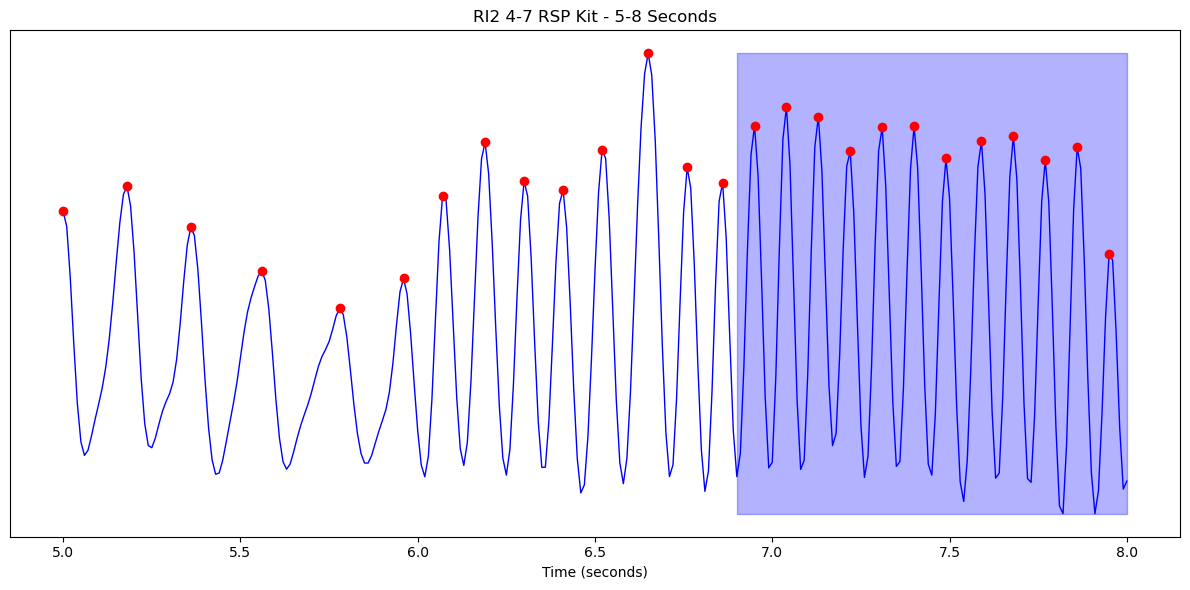

In [ ]:
RI2_4_7_kit.plot(start_time=5, duration=3, behavior_data=True, show_peaks=True, title="RI2 4-7 RSP Kit")

Index(['Timestamps', 'Respiration Value', 'Behavioral Event', 'Peaks'], dtype='object')
Behavioral data is present, overlaying behavior events.


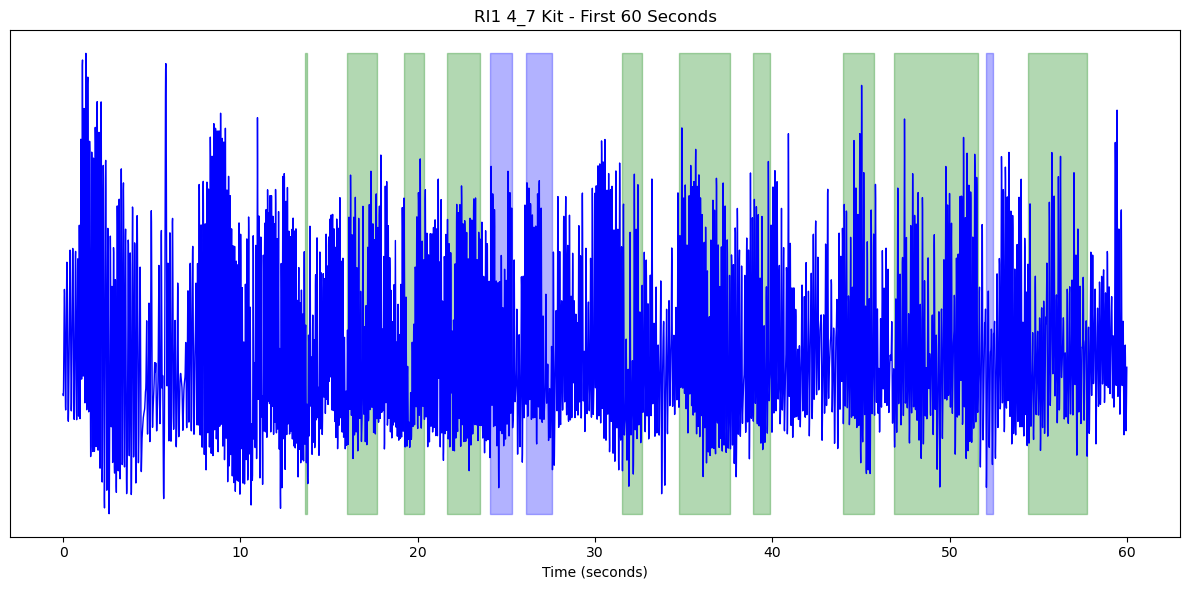

In [ ]:
RI1_4_7_kit.plot(duration=60, behavior_data=True, title="RI1 4_7 Kit")

Index(['Timestamps', 'Respiration Value', 'Behavioral Event', 'Peaks'], dtype='object')
Behavioral data is present, overlaying behavior events.


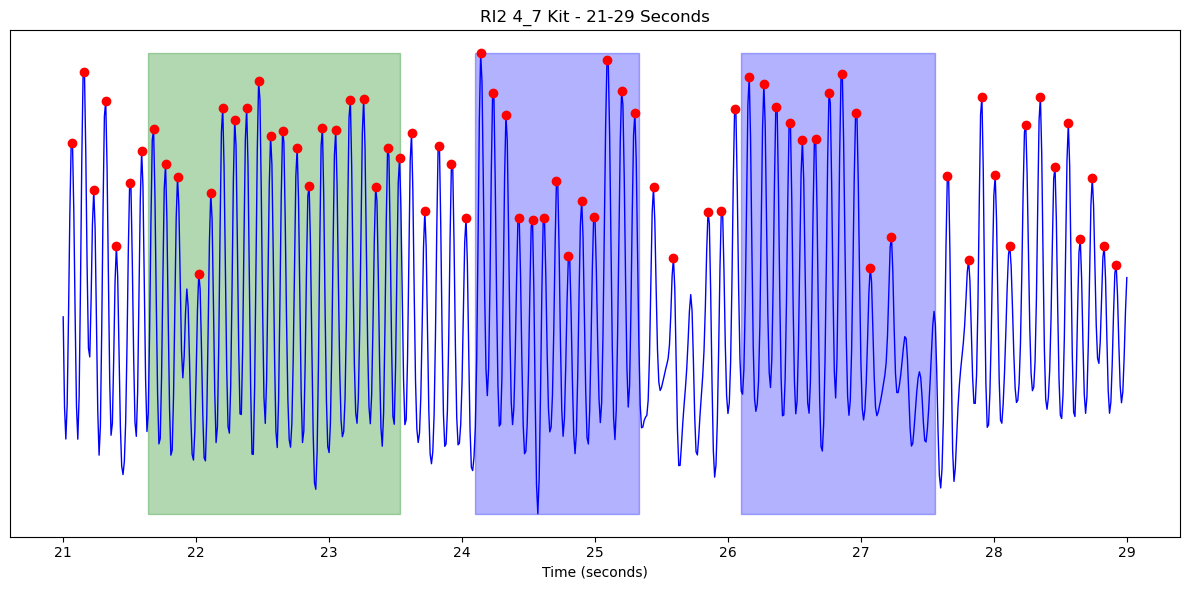

In [ ]:
RI1_4_7_kit.plot(start_time=21, duration=8, behavior_data=True, show_peaks=True, title="RI2 4_7 Kit")

Index(['Timestamps', 'Respiration Value', 'Behavioral Event', 'Peaks'], dtype='object')
Behavioral data is present, overlaying behavior events.


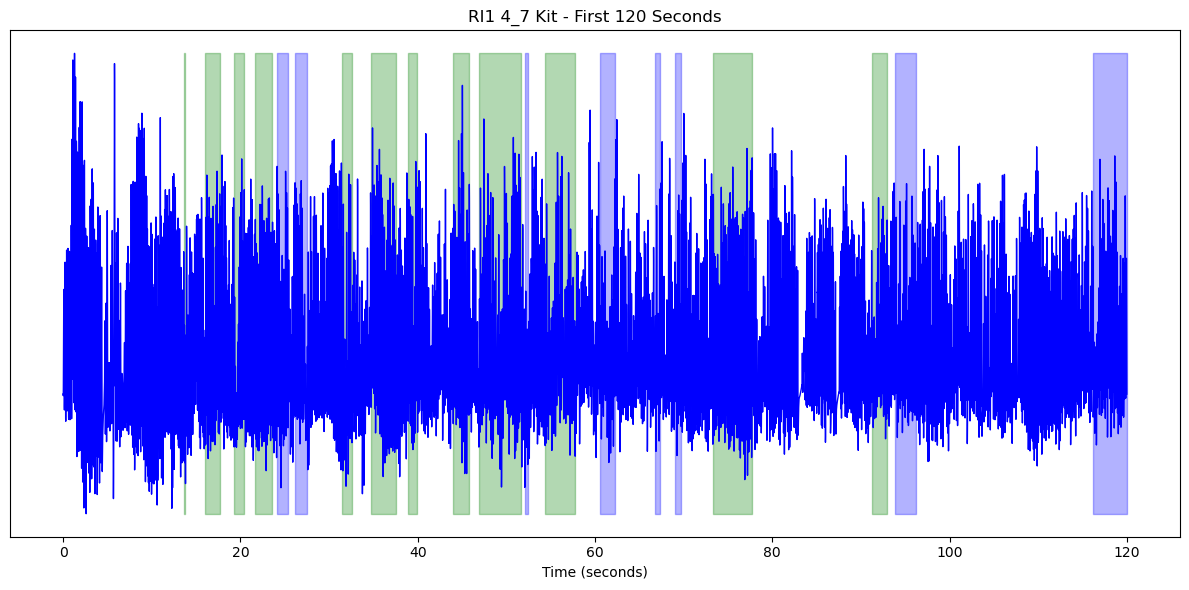

In [ ]:
RI1_4_7_kit.plot(duration=120, behavior_data=True, title="RI1 4_7 Kit")

Index(['Timestamps', 'Respiration Value', 'Behavioral Event', 'Peaks'], dtype='object')
Behavioral data is present, overlaying behavior events.


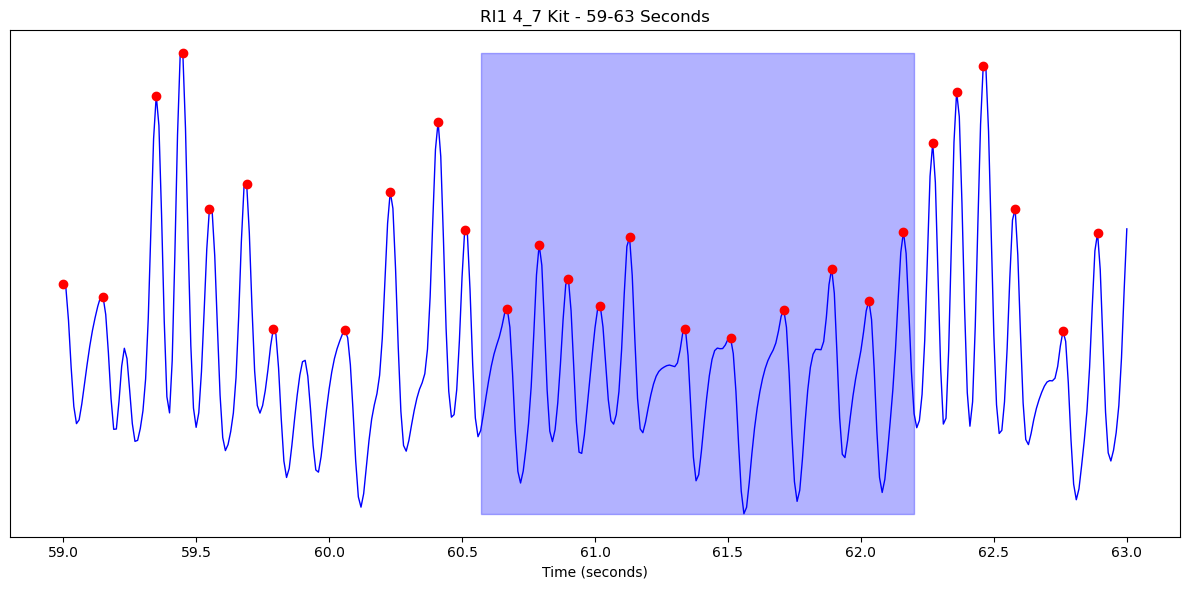

In [ ]:
RI1_4_7_kit.plot(start_time=59, duration=4, behavior_data=True, peak_sel=.1, peak_thresh=200, show_peaks=True, title="RI1 4_7 Kit")

In [ ]:
# Display the first 20 rows of the DataFrame with 'Behavioral Event' not equal to 'None'
RI2_4_7_boris.head(20)

,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,Observation duration by subject by observation,Behavior,Behavioral category,Behavior type,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop
1,RI2_s4_7_p5_2_nRB3,2025-07-01 08:59:12.130,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,0.0,598.466,605.233,30.0,subject,136.8,facial sniffing,Not defined,STATE,6.900,9.533,2.633,C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,207.0,286.0,NaN,NaN,NaN,NaN
3,RI2_s4_7_p5_2_nRB3,2025-07-01 08:59:12.130,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,0.0,598.466,605.233,30.0,subject,136.8,facial sniffing,Not defined,STATE,13.900,14.267,0.367,C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,417.0,428.0,NaN,NaN,NaN,NaN
7,RI2_s4_7_p5_2_nRB3,2025-07-01 08:59:12.130,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,0.0,598.466,605.233,30.0,subject,136.8,Posturing,Not defined,STATE,18.833,20.667,1.834,C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,565.0,620.0,NaN,NaN,NaN,NaN
15,RI2_s4_7_p5_2_nRB3,2025-07-01 08:59:12.130,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,0.0,598.466,605.233,30.0,subject,136.8,Posturing,Not defined,STATE,46.100,52.100,6.000,C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,1383.0,1563.0,NaN,NaN,NaN,NaN
31,RI2_s4_7_p5_2_nRB3,2025-07-01 08:59:12.130,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,0.0,598.466,605.233,30.0,subject,136.8,Posturing,Not defined,STATE,132.867,141.767,8.900,C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,3986.0,4253.0,NaN,NaN,NaN,NaN
49,RI2_s4_7_p5_2_nRB3,2025-07-01 08:59:12.130,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,0.0,598.466,605.233,30.0,subject,136.8,Posturing,Not defined,STATE,259.367,269.300,9.933,C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,7781.0,8079.0,NaN,NaN,NaN,NaN
54,RI2_s4_7_p5_2_nRB3,2025-07-01 08:59:12.130,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,0.0,598.466,605.233,30.0,subject,136.8,Posturing,Not defined,STATE,322.433,338.667,16.234,C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,9674.0,10161.0,NaN,NaN,NaN,NaN
59,RI2_s4_7_p5_2_nRB3,2025-07-01 08:59:12.130,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,0.0,598.466,605.233,30.0,subject,136.8,Posturing,Not defined,STATE,356.300,382.300,26.000,C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,10690.0,11470.0,NaN,NaN,NaN,NaN
65,RI2_s4_7_p5_2_nRB3,2025-07-01 08:59:12.130,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,0.0,598.466,605.233,30.0,subject,136.8,Posturing,Not defined,STATE,409.167,422.267,13.100,C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,12276.0,12669.0,NaN,NaN,NaN,NaN
72,RI2_s4_7_p5_2_nRB3,2025-07-01 08:59:12.130,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,0.0,598.466,605.233,30.0,subject,136.8,Posturing,Not defined,STATE,444.500,448.567,4.067,C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4,13336.0,13458.0,NaN,NaN,NaN,NaN


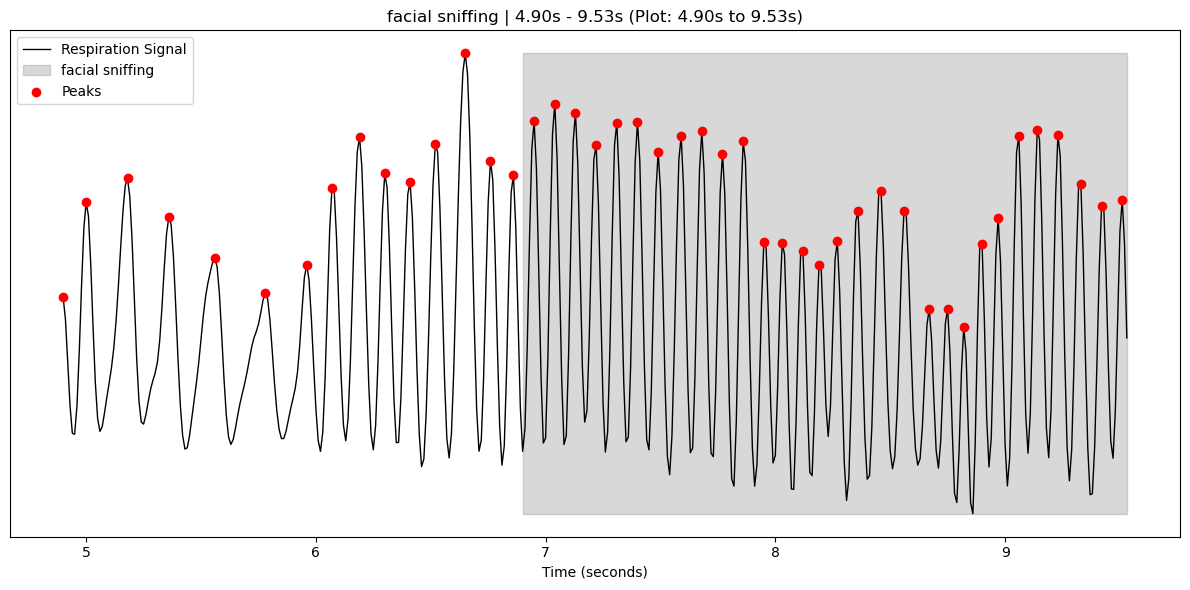

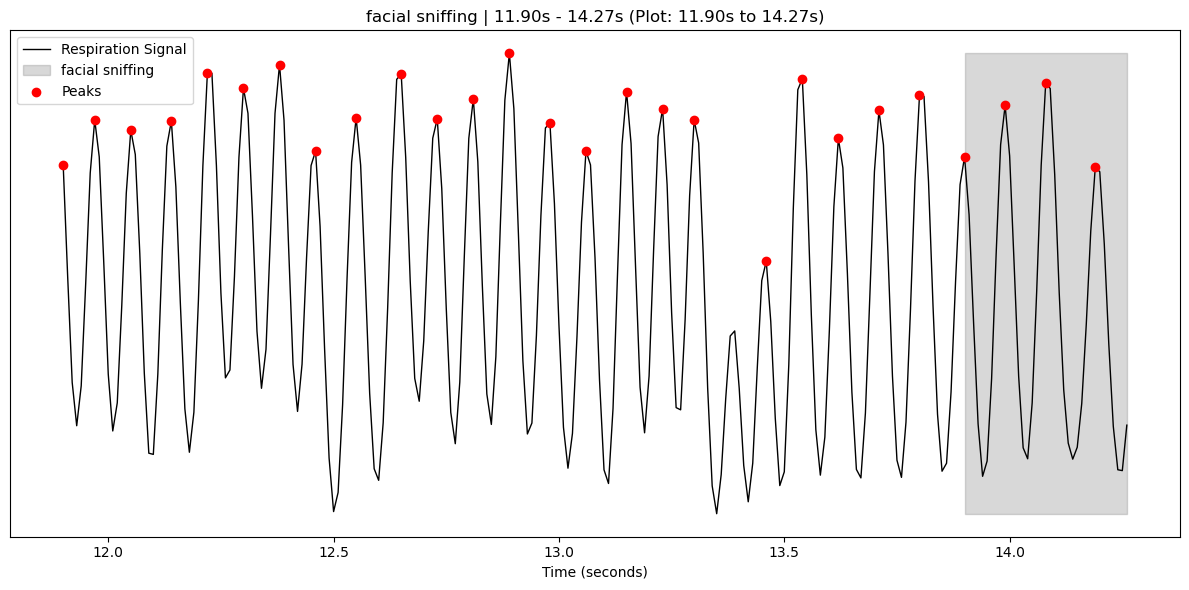

Skipping behavior 'Posturing' (excluded).
Skipping behavior 'Posturing' (excluded).
Skipping behavior 'Posturing' (excluded).
Skipping behavior 'Posturing' (excluded).
Skipping behavior 'Posturing' (excluded).
Skipping behavior 'Posturing' (excluded).
Skipping behavior 'Posturing' (excluded).
Skipping behavior 'Posturing' (excluded).
Skipping behavior 'Posturing' (excluded).
Skipping behavior 'Posturing' (excluded).
Skipping behavior 'Posturing' (excluded).
Skipping behavior 'Posturing' (excluded).


In [ ]:
RI2_4_7_kit.plot_each_behavior_event(show_peaks=True, pre_behavior=2, peak_sel=.1, peak_thresh=.1, exclude='Posturing')